# Axial Fan Performance Curve Workflow

### Contributors: Mustafa Kaddoura, Achilleas Krikas 
### Product Version: Ansys Fluent 2026 R1   

## Overview
The axial fan performance curve workflow demonstrates basic end to end comprehensive solution for simulating an axial fan and constructing its performance curve. This example also demonstrate using Python APIs capabilities to setup complex workflows and to run parametric studies.

This workflow includes:
- Importing a CFD mesh
- Creating input parameters
- Setting up the solver
- Creating report definitions and output parameters
- Initiating and running a parametric study.
- Plotting fan performance curve.

![alt text](problem_schematic.png)

## Import required libraries and download required files

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt

import ansys.fluent.core as pyfluent
from ansys.fluent.core import examples

# Download the example mesh file
# import_file_name = examples.download_file(
#     "axial_fan.msh",
#     "pyfluent/axial_fan_perfrormance_curve",
#     save_path=os.getcwd(),
# )

## Launch Fluent

Launch Fluent in solution mode with double precission running on eight processors.

In [26]:
solver = pyfluent.launch_fluent(
    mode="solver",
    processor_count = 8,
    precision="double",
    ui_mode='gui',
    cleanup_on_exit=True
)

## Read mesh file and perform mesh check

Import the mesh and perform a mesh check, which lists the minimum and maximum x, y, and z values from the mesh in the default SI units of meters. The mesh check also reports a number of other mesh features that are checked.

In [ ]:
#### DELETE THESE LINES IF DOWNLOADING THE MESH FILE FROM THE EXAMPLES DIRECTORY
# import mesh file from local dirctory
import_file_name = r'D:\generic_fan_case\Pyfluent\PyFluent_Example_Sharable\axial_fan_case\axial_fan.msh.h5'
###########################

solver.settings.file.read_mesh(file_name = import_file_name)
solver.settings.mesh.check()

Fast-loading "C:\PROGRA~1\ANSYSI~1\v261\fluent\fluent26.1.0\\addons\afd\lib\hdfio.bin"
Done.

Reading from SNPS-saQ3UISrNo:"D:\generic_fan_case_Achilleas\Pyfluent\PyFluent_Example_Sharable\axial_fan_case\axial_fan.msh.h5" in NODE0 mode ...
  Reading mesh ...
       56963 cells,     3 cell zones ...
          21750 polyhedra cells,  zone id: 8871
          28418 polyhedra cells,  zone id: 8874
           6795 polyhedra cells,  zone id: 8877
      394111 faces,    12 face zones ...
          40814 polygonal interior faces,  zone id: 8876
         189348 polygonal interior faces,  zone id: 8873
         147474 polygonal interior faces,  zone id: 8870
            361 polygonal internal faces,  zone id: 54
            439 polygonal internal faces,  zone id: 53
            610 polygonal wall faces,  zone id: 52
           2544 polygonal wall faces,  zone id: 51
           5857 polygonal wall faces,  zone id: 50
           5908 polygonal wall faces,  zone id: 49
            491 polygonal pres

## Creat inpt parameters

Create named expressions for the pressure outlet boundary condition and for the fan rotational speed, and set them as input parameters. Pressure outlet value is set to 0.0 Pa (atmospheric gage pressure) and rotational speed is set to 155.534 rad/s.

In [28]:
# Create a named expression to parameterize the pressure outlet value
solver.settings.setup.named_expressions.create(name="pressure_outlet")
solver.settings.setup.named_expressions['pressure_outlet'].definition = '0 [Pa]'
solver.settings.setup.named_expressions['pressure_outlet'].input_parameter = True

# Create a named expression to parameterize the rotational speed value
solver.settings.setup.named_expressions.create(name = 'rotational_speed')
solver.settings.setup.named_expressions['rotational_speed'].definition = '155.534 [rad/s]'
solver.settings.setup.named_expressions['rotational_speed'].input_parameter = True

## Solver setup

Set the solver type to pressure-based, and analysis type to steady state, and activate gravity in the negative x-direction.

In [29]:
# General: Solver Type: Pressure-Based
solver.settings.setup.general.solver.type = 'pressure-based'

# General: Time: Steady State
solver.settings.setup.general.solver.time = 'steady'

# General: activate gravity
solver.settings.setup.general.operating_conditions.gravity.enable = True
solver.settings.setup.general.operating_conditions.gravity.components = [-9.81, 0, 0]

## Models: Turbulance/Viscous Model

Set the turbulance/viscous model to SST k-omega model. Activate curvature correction, production Kato-Launder, and production limiter options.

In [30]:
solver.settings.setup.models.viscous.model = 'k-omega'
solver.settings.setup.models.viscous.k_omega_model = 'sst'
solver.settings.setup.models.viscous.options.curvature_correction.enabled= True
solver.settings.setup.models.viscous.options.production_kato_launder_enabled = True
solver.settings.setup.models.viscous.options.production_limiter.enabled='True'

## Cell Zones

Activate the Multiple Reference Frame (MRF) model for the <code>'rotating-fan'</code> zone, specify the Y-axis as axis of rotation, and set the rotational speed using the previously defined input parameter. Keep the default setting for the remaining cell zones.

In [31]:
# Activate MRF model for the 'rotating fan' zone
solver.settings.setup.cell_zone_conditions.fluid['rotating-fan'].reference_frame.frame_motion = True

# Assign the rotational speed value to the MRF angular velocity parameter
solver.settings.setup.cell_zone_conditions.fluid['rotating-fan'].reference_frame.mrf_omega.value = 'rotational_speed'

# rotating fan zone: Specify Rotation-Axis Direction (X, Y, Z): [0,1,0] for Y-axis rotation
solver.settings.setup.cell_zone_conditions.fluid['rotating-fan'].reference_frame.reference_frame_axis_direction[0].value = 0
solver.settings.setup.cell_zone_conditions.fluid['rotating-fan'].reference_frame.reference_frame_axis_direction[1].value = 1
solver.settings.setup.cell_zone_conditions.fluid['rotating-fan'].reference_frame.reference_frame_axis_direction[2].value = 0

## Boundary conditions

Set the <code>'inlet'</code> boundary as pressure-inlet boundary condition type, and assign to it a presure value of 0.0 Pa (atmospheric gage pressure).
Set the <code>'pressure-outlet'</code> boundary as pressure-outlet boundary condition type, and assign to it the previously defined input parameter.
Keep the remaining boundaries as no-slip wall boundary condition type (default settings - no changes)

In [32]:
# Boundary conditions: 'inlet' boundary: type: Pressure Inlet
solver.settings.setup.boundary_conditions.set_zone_type(new_type = 'pressure-inlet', zone_list = ['inlet'])
solver.settings.setup.boundary_conditions.pressure_inlet['inlet'].momentum.gauge_total_pressure.value = 0
solver.settings.setup.boundary_conditions.pressure_inlet['inlet'].turbulence.turbulence_specification = 'Intensity and Viscosity Ratio'
solver.settings.setup.boundary_conditions.pressure_inlet['inlet'].turbulence.turbulent_intensity = 0.05
solver.settings.setup.boundary_conditions.pressure_inlet['inlet'].turbulence.turbulent_viscosity_ratio = 10

# Boundary conditions: 'pressure-outlet' boundary: type: Pressure Outlet
solver.settings.setup.boundary_conditions.set_zone_type(new_type = 'pressure-outlet', zone_list = ['pressure-outlet'])
solver.settings.setup.boundary_conditions.pressure_outlet['pressure-outlet'].momentum.gauge_pressure.value = 'pressure_outlet'
solver.settings.setup.boundary_conditions.pressure_outlet['pressure-outlet'].turbulence.turbulence_specification = 'Intensity and Viscosity Ratio'
solver.settings.setup.boundary_conditions.pressure_outlet['pressure-outlet'].turbulence.turbulent_intensity = 0.05
solver.settings.setup.boundary_conditions.pressure_outlet['pressure-outlet'].turbulence.turbulent_viscosity_ratio = 10

A newer syntax is available to perform the last operation:
solver.settings.setup.boundary_conditions.pressure_outlet['pressure-outlet'].turbulence.backflow_turbulent_intensity = 0.05
A newer syntax is available to perform the last operation:
solver.settings.setup.boundary_conditions.pressure_outlet['pressure-outlet'].turbulence.backflow_turbulent_viscosity_ratio = 10


## Solution methods and controls

Set the pressure-velocity coupling scheme and spatial discretization methods. Also, set the under-relaxation factors.

In [33]:
# Solution methods
solver.settings.solution.methods.p_v_coupling.flow_scheme = 'SIMPLEC'
solver.settings.solution.methods.spatial_discretization.discretization_scheme['pressure'] = 'presto!'
solver.settings.solution.methods.spatial_discretization.discretization_scheme['mom'] = 'first-order-upwind'
solver.settings.solution.methods.spatial_discretization.discretization_scheme['k'] = 'first-order-upwind'
solver.settings.solution.methods.spatial_discretization.discretization_scheme['omega'] = 'first-order-upwind'

# Solution controls: Under-relaxation factors
solver.settings.solution.controls.under_relaxation['pressure'] = 0.3
solver.settings.solution.controls.under_relaxation['mom'] = 0.7
solver.settings.solution.controls.under_relaxation['k'] = 0.6
solver.settings.solution.controls.under_relaxation['omega'] = 0.6
solver.settings.solution.controls.under_relaxation['turb-viscosity'] = 0.8

## Create report definitions and output parameters

Create report definitions for computed quantities of interest including, inlet volume flow rate, total-to-static pressure difference, and torque.

In [34]:
# Report definition: Inlet volume flow rate
solver.settings.solution.report_definitions.surface.create(name = 'inlet-volume-flow-rate')
solver.settings.solution.report_definitions.surface['inlet-volume-flow-rate'] = {'report_type' : 'surface-volumeflowrate'}
solver.settings.solution.report_definitions.surface['inlet-volume-flow-rate'].surface_names = ['inlet']
solver.settings.solution.report_definitions.surface['inlet-volume-flow-rate'].create_report_file = True
solver.settings.solution.report_definitions.surface['inlet-volume-flow-rate'].create_report_plot = True
solver.settings.solution.report_definitions.surface['inlet-volume-flow-rate'].output_parameter = True

# Report definition: Outlet static pressure  (Ps,out)
solver.settings.solution.report_definitions.surface.create(name = 'p_static_out')
solver.settings.solution.report_definitions.surface['p_static_out'] = {'report_type' : 'surface-areaavg'}
solver.settings.solution.report_definitions.surface['p_static_out'].surface_names = ['pressure-outlet']
solver.settings.solution.report_definitions.surface['p_static_out'].create_report_file = True
solver.settings.solution.report_definitions.surface['p_static_out'].create_report_plot = True

# Report definition: Inlet total pressure (Pt,in)
solver.settings.solution.report_definitions.surface.create(name = 'p_total_in')
solver.settings.solution.report_definitions.surface['p_total_in'] = {'report_type' : 'surface-areaavg'}
solver.settings.solution.report_definitions.surface['p_total_in'].field = 'total-pressure'
solver.settings.solution.report_definitions.surface['p_total_in'].surface_names = ['inlet']
solver.settings.solution.report_definitions.surface['p_total_in'].create_report_file = True

# Report definition: Total-to-static pressure difference: Pts = Ps,out - Pt,in
solver.settings.solution.report_definitions.single_valued_expression.create(name = 'total-to-static-pressure')
solver.settings.solution.report_definitions.single_valued_expression['total-to-static-pressure'].definition = '{p_static_out}-{p_total_in}'
solver.settings.solution.report_definitions.single_valued_expression['total-to-static-pressure'].output_parameter = True
solver.settings.solution.report_definitions.single_valued_expression['total-to-static-pressure'].create_report_file = True
solver.settings.solution.report_definitions.single_valued_expression['total-to-static-pressure'].create_report_plot = True

# Report definition: Torque
solver.settings.solution.report_definitions.moment.create(name = 'torque')
solver.settings.solution.report_definitions.moment['torque'] = {'report_type' : 'moment'}
solver.settings.solution.report_definitions.moment['torque'].report_output_type = 'Moment'
solver.settings.solution.report_definitions.moment['torque'].zones = ['fan-walls']
solver.settings.solution.report_definitions.moment['torque'].create_report_file = True
solver.settings.solution.report_definitions.moment['torque'].create_report_plot = True
solver.settings.solution.report_definitions.moment['torque'].output_parameter = True

## Set the number of iterations for the calculation and enable convergence condition check

Set the number of solution iterations to 2500, and enable the convergence condition check.

In [35]:
solver.settings.solution.run_calculation.parameters.iter_count = 2500

solver.settings.solution.monitor.residual.options.criterion_type = "absolute"

## Save case file

Write the case with all settings in place.

In [36]:
solver.settings.file.write_case(file_name="axial_fan.cas.h5")


Writing to SNPS-saQ3UISrNo:"d:\generic_fan_case_Achilleas\Pyfluent\PyFluent_Example_Sharable\axial_fan_case\axial_fan.cas.h5" in NODE0 mode and compression level 1 ...
Grouping cells for Laplace smoothing ...
  Done.       56963 cells,     3 zones ...
      394173 faces,    13 zones ...
      331597 nodes,     1 zone  ...
  Done.
Done.


## Initialize parametric study

Initialize a parametric design point study from a Fluent session.

In [37]:
solver.settings.parametric_studies.initialize(project_filename="project_axial_fan")


Writing to SNPS-saQ3UISrNo:"D:/generic_fan_case_Achilleas/Pyfluent/PyFluent_Example_Sharable/axial_fan_case/project_axial_fan.cffdb/axial_fan-Solve/axial_fan.cas.h5" in NODE0 mode and compression level 1 ...
Grouping cells for Laplace smoothing ...
       56963 cells,     3 zones ...
      394173 faces,    13 zones ...
      331597 nodes,     1 zone  ...
  Done.
Done.


## Access and modify input parameters

Access and modify the input parameters of the base design point. Set the pressure at the outlet boundary to 25 Pa, and keep the fan's rotational speed at 155.534 rad/s.

In [38]:
# Update the Base Design Point
solver.settings.parametric_studies["axial_fan-Solve"].design_points[
    "Base DP"
].input_parameters = {
    "pressure_outlet": 25,
    "rotational_speed": 155.534,
}

## Add new design points

Create four new design points and assign outlet pressure and rotational speed to each one. The fan's rotational speed is set constant in this study.

In [39]:
# Add four more design points to the parametric study
solver.settings.parametric_studies["axial_fan-Solve"].design_points.create(write_data=False, capture_simulation_report_data=True)
solver.settings.parametric_studies["axial_fan-Solve"].design_points.create(write_data=False, capture_simulation_report_data=True)
solver.settings.parametric_studies["axial_fan-Solve"].design_points.create(write_data=False, capture_simulation_report_data=True)
solver.settings.parametric_studies["axial_fan-Solve"].design_points.create(write_data=False, capture_simulation_report_data=True)

# Update input parameters for the new design points
solver.settings.parametric_studies["axial_fan-Solve"].design_points[
    "DP1"].input_parameters = {
    "pressure_outlet": 50,
    "rotational_speed": 155.534,
}
solver.settings.parametric_studies["axial_fan-Solve"].design_points[
    "DP2"].input_parameters = {
    "pressure_outlet": 125,
    "rotational_speed": 155.534,
}
solver.settings.parametric_studies["axial_fan-Solve"].design_points[
    "DP3"].input_parameters = {
    "pressure_outlet": 150,
    "rotational_speed": 155.534,
}
solver.settings.parametric_studies["axial_fan-Solve"].design_points[
    "DP4"].input_parameters = {
    "pressure_outlet": 200,
    "rotational_speed": 155.534,
}

## Save the current parametric project

In [40]:
solver.settings.file.parametric_project.save()


Project saved successfully at "D:/generic_fan_case_Achilleas/Pyfluent/PyFluent_Example_Sharable/axial_fan_case/project_axial_fan.flprj"


## Update all design points

Update all design points by running the CFD simulation for every design point. 

In [41]:
solver.settings.parametric_studies["axial_fan-Solve"].design_points.update_all()


Writing to SNPS-saQ3UISrNo:"D:/generic_fan_case_Achilleas/Pyfluent/PyFluent_Example_Sharable/axial_fan_case/project_axial_fan.cffdb\axial_fan-Solve\BaseCases\axial_fan.cas.h5" in NODE0 mode and compression level 1 ...
Grouping cells for Laplace smoothing ...
       56963 cells,     3 zones ...
      394173 faces,    13 zones ...
      331597 nodes,     1 zone  ...
  Done.
Done.

Opening input/output transcript to file "D:/generic_fan_case_Achilleas/Pyfluent/PyFluent_Example_Sharable/axial_fan_case/project_axial_fan.cffdb/axial_fan-Solve/Base DP\Auto-generated-transcript.trn".

-------------------------------------------------------------------------------------
ID    Hostname         Core  O.S.         PID    CPU Model Name                     
-------------------------------------------------------------------------------------
n7    SNPS-saQ3UISrNo  8/20  Windows-x64  40284  Intel(R) Core(TM) Ultra 7 265HX    
n6    SNPS-saQ3UISrNo  7/20  Windows-x64  16704  Intel(R) Core(TM) Ultra 

## Save current parametric project

In [42]:
solver.settings.file.parametric_project.save()


Project saved successfully at "D:/generic_fan_case_Achilleas/Pyfluent/PyFluent_Example_Sharable/axial_fan_case/project_axial_fan.flprj"


## Export the design table

Export the design point table to a CSV file.

In [43]:
# parametric_table_save_path = os.path.join(working_directory, 'design_point_table_study.csv')
solver.settings.parametric_studies.export_design_table(
    filepath = '../../../design_point_table_study.csv'
)

Design point table exported successfully to "../../../design_point_table_study.csv" 


## Plotting fan performance curve

Plot the computed total-to-static pressure rise versus the inlet volume flow rate.

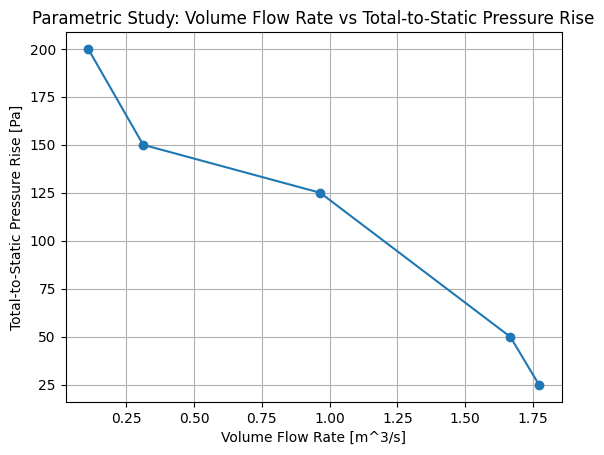

In [ ]:
# Load the design point study results data from the CSV file
file = 'design_point_table_study.csv'
data = np.loadtxt(file, delimiter=',', skiprows=2, usecols=range(1,6))

# Plot the results data
plt.plot(data[:, 2], data[:, 4], "-o")

# Set x- and y-axis labels, title, and grid
plt.xlabel("Volume Flow Rate [m^3/s]")
plt.ylabel("Total-to-Static Pressure Rise [Pa]")
plt.title("Parametric Study: Volume Flow Rate vs Total-to-Static Pressure Rise")
plt.grid(True)

# Display the plot
plt.show()

## Closing Fluent

Close Fluent session.

In [45]:
solver.exit()